#### A BFE characterization of the TNG-3-dark halo 21537 
Diemer BFE implementation example

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

import numpy as np
import h5py
import sys

sys.path.append('../src/')
# from density_profiles import read_density_profile  # Removed: function not found here
sys.path.append('../src/exp')
sys.path.append('../src/hydrotools')

from data_ios import read_density_profile  # Correct import

import data_ios 
#from config import DATA_PATH, TEMP_DATA_PATH, FIGURES_PATH

from basis_helpers import compute_basis
from density_profiles import empirical_density_profile
import pyEXP

plt.style.use("../src/illustris_bfe.mplstyle")

In [11]:
density_filename = '../data/tng35-3-dark/halo_21537_density_profiles.hdf5'
r_norm_fit, rho_norm_fit = np.loadtxt("../data/dimer_density_profile_fit.txt")

In [14]:
sim_snap, sim_z, sim_t, _ = np.loadtxt("../data/tng35-3-dark/tng35-3-dark_halo_time_evol.txt", 
                                       skiprows=4, unpack=True)

halo_params = data_ios.read_halo_params("../data/tng35-3-dark/halo_21537_params.hdf5")
r200c = halo_params['R200c']
M200c = halo_params['M200c']
c200c = halo_params['c200c']
rho200c = halo_params['M200c']/(4/3. * np.pi * halo_params['R200c']**3)
all_snaps = halo_params['snap']
rs = r200c / c200c


assert sim_snap[0] == all_snaps[0]
assert sim_snap[-1] == all_snaps[-1]
assert len(sim_snap) == len(all_snaps)

In [15]:
# Cell 4 asserts sim_snap and snap are aligned (same length, same order),
# so we can zip all parameters directly using snap as keys.
snap_arr = np.asarray(all_snaps, dtype=int)

M200c_halo  = {int(s): float(v) for s, v in zip(snap_arr, M200c)}
R200c_halo  = {int(s): float(v) for s, v in zip(snap_arr, r200c)}
c200c_halo  = {int(s): float(v) for s, v in zip(snap_arr, c200c)}
rho200c_halo = {int(s): float(v) for s, v in zip(snap_arr, rho200c)}
rs_halo     = {int(s): float(v) for s, v in zip(snap_arr, rs)}
z_halo  = {int(s): float(v) for s, v in zip(snap_arr, sim_z)}
t_halo  = {int(s): float(v) for s, v in zip(snap_arr, sim_t)}
snap_halo  = {int(s): float(v) for s, v in zip(snap_arr, sim_snap)}

init_snap = 2 
final_snap = 99

In [16]:
z_list = [0, 1, 2, 3, 4, 5, 6, 8, 10]
snap_list = []
for i in range(len(z_list)):
    idx = np.where(sim_z==z_list[i])[0][0]
    snap_list.append(int(sim_snap[idx]))
    assert z_halo[snap_list[i]] == z_list[i] 
print(snap_list)

[99, 50, 33, 25, 21, 17, 13, 8, 4]


/tmp/ipykernel_1059208/1045312229.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(rho/rho200c_halo[s]),


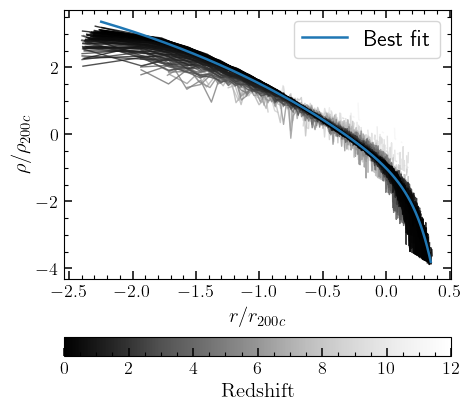

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
norm = mpl.colors.Normalize(vmin=z_halo[final_snap], vmax=z_halo[init_snap])
cmap = plt.cm.Greys_r

for s in range(init_snap, final_snap+1):
    r, rho = read_density_profile(density_filename, int(snap_halo[s]))
    ax.plot(np.log10(r/R200c_halo[s]), 
            np.log10(rho/rho200c_halo[s]), 
            color=cmap(norm(z_halo[s])), 
            ls='-', lw=1, alpha=0.8)
    

plt.plot(np.log10(r_norm_fit), np.log10(rho_norm_fit), c='C0', alpha=1,  label='Best fit', ls='-')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label=r'$\rm{Redshift}$', orientation='horizontal')

ax.legend(fontsize=16)
ax.set_xlabel(r'$r/r_{200c}$')
ax.set_ylabel(r'$\rho/\rho_{200c}$')
plt.savefig('../temp_figures/halo_21537_normalized_fit_density_profile.png', bbox_inches='tight')

In [22]:
# Example input arrays (replace with your actual data)
def build_basis(r_basis, rho_basis, nmax, lmax, Mtot=1):
    basis_params = {
        'rmin': r_basis[0],
        'rmax': r_basis[-1],
        'rmapping': 1.0,  # If rmapping is a float, otherwise use the correct type
        'Mtotal': 1.0,
        'nbins': 2000,
        'lmax': lmax,
        'nmax': nmax,
        'cachename': 'halo_21537_basis_cache_{:02d}_{:02d}.txt'.format(nmax, lmax),
        'modelname': 'halo_21537_model.txt'.format(nmax, lmax),
        'basis_id': 'sphereSL',
    }

    basis_path = './'
    basis_filename = 'halo_21537_basis_config_{:02d}_{:02d}.yaml'.format(nmax, lmax)

    basis = compute_basis(basis_params, r_basis, rho_basis, basis_path, basis_filename)
    return basis

In [23]:
nmax= 16
lmax = 8
#basis = build_basis(r/rvir[-1], profile_fit, nmax=nmax, lmax=lmax)
basis = build_basis(r_norm_fit, rho_norm_fit, nmax=nmax, lmax=lmax)

! Scaling: R = 2.242836995489568  M = 1.0
Scaling factors: rfac = 1.0, dfac = 0.32058292304121716, mfac = 0.32058292304121727, pfac = 0.3205829230412172
---- SLGridSph::ReadH5Cache: successfully read basis cache <halo_21537_basis_cache_16_08.txt>
---- Spherical::orthoTest: worst=0.000921396


In [30]:
get_basis = basis.getBasis(1e-2, 1.2, numr=400)

In [38]:
get_basis[8][0]['density']

array([ 1.05875353e+00,  9.99955798e-01,  9.43949567e-01,  8.90626121e-01,
        8.39886950e-01,  7.91627777e-01,  7.45753476e-01,  7.02166664e-01,
        6.60777297e-01,  6.21493430e-01,  5.84229125e-01,  5.48899479e-01,
        5.15422246e-01,  4.83717285e-01,  4.53707775e-01,  4.25318978e-01,
        3.98478701e-01,  3.73116738e-01,  3.49165700e-01,  3.26559878e-01,
        3.05236276e-01,  2.85133920e-01,  2.66194851e-01,  2.48362011e-01,
        2.31580616e-01,  2.15799590e-01,  2.00967684e-01,  1.87037396e-01,
        1.73960976e-01,  1.61694069e-01,  1.50194287e-01,  1.39420603e-01,
        1.29333543e-01,  1.19895777e-01,  1.11071539e-01,  1.02826278e-01,
        9.51274557e-02,  8.79434454e-02,  8.12445537e-02,  7.50024460e-02,
        6.91909814e-02,  6.37834652e-02,  5.87554901e-02,  5.40836200e-02,
        4.97459082e-02,  4.57215784e-02,  4.19907440e-02,  3.85343910e-02,
        3.53354275e-02,  3.23766101e-02,  2.96418916e-02,  2.71162043e-02,
        2.47855478e-02,  

In [9]:
def read_tng_halo_particles(filename):
    """
    Read halo particle coordinates and group properties from a TNG HDF5 file.

    The function automatically detects the halo ID contained in the key
    'galaxy_XXXXXX_ptldm_Coordinates'.

    Parameters
    ----------
    filename : str
        Path to HDF5 file.

    Returns
    -------
    coords : ndarray, shape (N,3)
        Dark matter particle positions [kpc].
    M200c : float
        Halo M200c mass.
    R200c : float
        Halo R200c radius.
    halo_id : str
        Halo ID string extracted from file.
    """
    mass_tng = 2.33443590182933*1e7

    with h5py.File(filename, 'r') as f:

        # Find coordinate key dynamically
        coord_key = None
        for key in f.keys():
            if key.startswith("galaxy_") and key.endswith("_ptldm_Coordinates"):
                coord_key = key
                break

        if coord_key is None:
            raise KeyError("No halo coordinate key found in file.")

        halo_id = coord_key.split('_')[1]

        coords = f[coord_key][:]
     
    marr = np.ones(len(coords)) * mass_tng
    return coords, marr 

In [10]:
import os
from exp_coefficients import compute_exp_coefs

sim = "tng35-3-dark"
halo_subfind_id = 21537
mass_tng = 2.33443590182933*1e7
units = [('mass', 'Msun', mass_tng),
             ('length', 'kpc', 1.0),
             ('velocity', 'km/s', 1.0),
             ('G', 'mixed', 43007.1)]

snap_basename = "galaxies_halo_{subfind_id}_tng50-3-dark_{snap:03d}.hdf5"

for s in all_snaps:
    input_snap = os.path.join("../data", sim, snap_basename.format(subfind_id=halo_subfind_id, snap=s))
    coords, masses = read_tng_halo_particles(input_snap)

    halo_data = {
        'pos': coords / R200c_halo[s],
        'mass': masses / (rho200c_halo[s] * R200c_halo[s]**3),
    }

    compute_exp_coefs(
        halo_data=halo_data,
        snap_time=z_halo[s],
        basis=basis,
        component='halo',
        coefs_file='halo_21537_coefficients_{:02d}_{:02d}.h5'.format(nmax, lmax),
        unit_system=units,
    )

> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done computing coefficients*
> Done c

KeyboardInterrupt: 

In [43]:
from grid import Grid3D

def bfe_density_profiles(
    basis,
    coefs,
    r_bins,
    theta_bins=20,
    phi_bins=40,
    time=0.0,
    field="dens",
    statistic="weighted_mean",
):
    """
    Compute a spherically averaged density profile from a BFE by
    sampling the density field on a spherical grid at specified
    radial bin centers.

    Parameters
    ----------
    basis : pyEXP basis object
    coefs : pyEXP coefficients
    r_bins : array-like
        Radial bin centers at which the density is evaluated.
    theta_bins : int, optional
        Number of polar-angle samples.
    phi_bins : int, optional
        Number of azimuthal samples.
    time : float, optional
        Snapshot time.
    field : str, optional
        Field name to extract (default: 'dens').
    statistic : {'weighted_mean', 'mean', 'median'}, optional
        Angular statistic to compute at each radius. 'weighted_mean'
        uses sin(theta) weighting to approximate a true spherical average.

    Returns
    -------
    ndarray
        Spherically averaged density evaluated at each radius.
    """

    r_bins = np.asarray(r_bins)

    # Build spherical grid at bin centers
    grid = Grid3D(
        system="spherical",
        ranges=[(r_bins.min(), r_bins.max()), None, None],
        num_points=[len(r_bins), theta_bins, phi_bins],
        r_bins=r_bins,
    )

    xyz = grid.to("cartesian")

    # Evaluate field
    fields = pyEXP.field.FieldGenerator([time], xyz)
    field_data = fields.points(basis, coefs)[time]

    if field not in field_data:
        raise ValueError(
            f"Field '{field}' not available. "
            f"Available fields: {list(field_data.keys())}"
        )

    dens = field_data[field]

    # Reshape: (nr, ntheta * nphi)
    nr = len(r_bins)
    dens = dens.reshape(nr, -1)

    if statistic == "weighted_mean":
        theta = np.linspace(0.0, np.pi, theta_bins)
        weights = np.sin(theta)[:, None] * np.ones((1, phi_bins))
        weights = weights.reshape(-1)
        profile = np.sum(dens * weights[None, :], axis=1) / np.sum(weights)
    elif statistic == "mean":
        profile = np.mean(dens, axis=1)
    elif statistic == "median":
        profile = np.median(dens, axis=1)
    else:
        raise ValueError("statistic must be 'weighted_mean', 'mean' or 'median'")

    return profile

In [44]:
coefs = pyEXP.coefs.Coefs.factory("halo_21537_coefficients_{:02d}_{:02d}.h5".format(nmax, lmax))


In [ ]:
bfe_prof = {}
rho_part = {}
r_part = {}

for s in snap_list:
    r_part[s], rho_part[s] = read_density_profile(density_filename, snap=s)

    bfe_prof[s] = bfe_density_profiles(
        basis=basis,
        coefs=coefs,
        r_bins=r_part[s]/R200c_halo[s],
        time=z_halo[s],
        statistic='weighted_mean',
        theta_bins=20,
        phi_bins=40,
    )


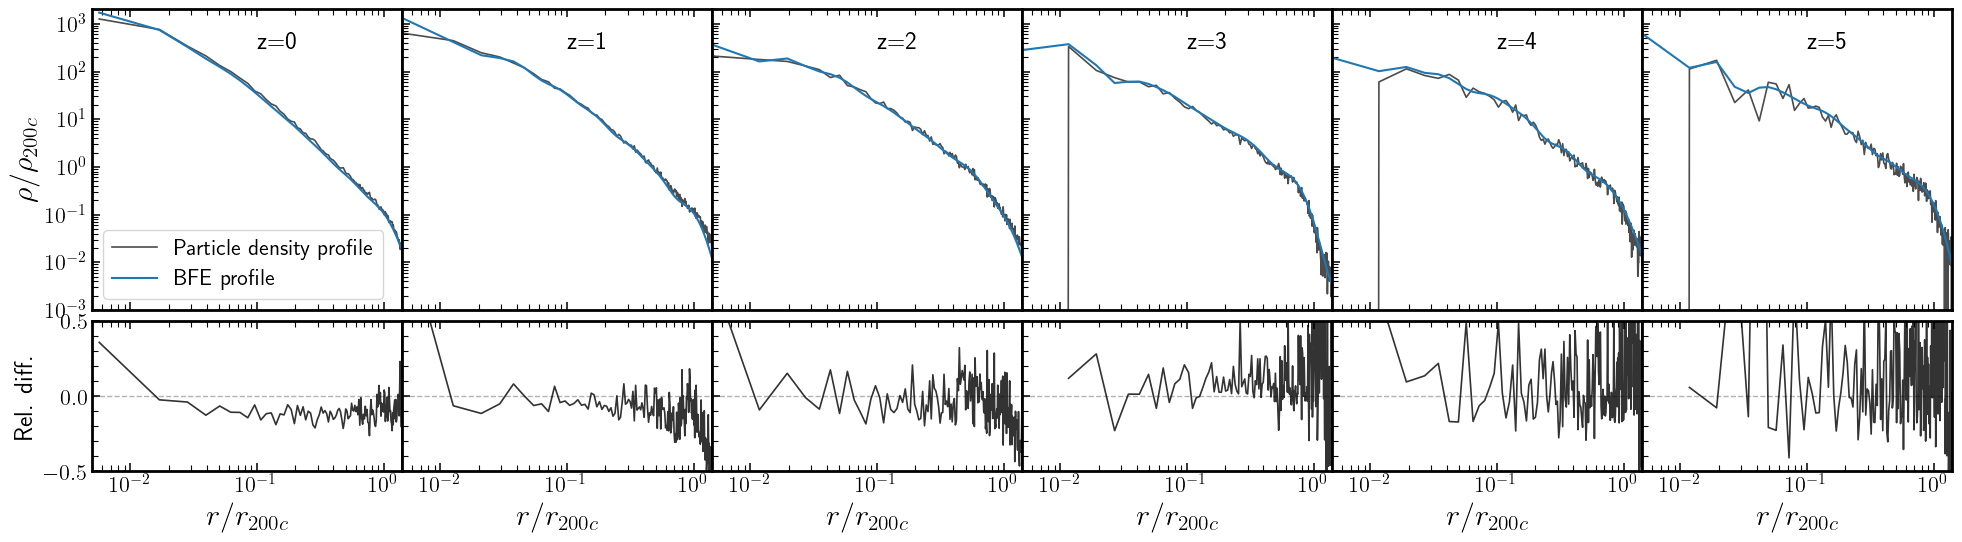

In [ ]:
import matplotlib.gridspec as gridspec
from fidelity_metrics import mise, mirse

fig = plt.figure(figsize=(24, 10))
gs = gridspec.GridSpec(
    4,
    6,
    figure=fig,
    height_ratios=[2, 1, 1, 1],
    hspace=0.08,
    wspace=0.0,
)

for idx, snap in enumerate(snap_list[:6]):
    ax_dens = fig.add_subplot(gs[0, idx])
    r_axis = r_part[snap] / R200c_halo[snap]
    rho_part_norm = rho_part[snap] / rho200c_halo[snap]

    ax_dens.loglog(
        r_axis,
        rho_part_norm,
        color='k',
        alpha=0.7,
        ls='-',
        lw=1.2,
        label='Particle density profile',
    )

    ax_dens.loglog(
        r_axis,
        np.abs(bfe_prof[snap]),
        lw=1.5,
        c='C0',
        alpha=1,
        label='BFE profile',
    )

    ax_dens.text(1e-1, 3e2, 'z={:.0f}'.format(z_halo[snap]), fontsize=18)
    ax_dens.set_xlim(0.5e-2, 1.4)
    ax_dens.set_ylim(1e-3, 2e3)
    ax_dens.yaxis.tick_left()
    plt.setp(ax_dens.get_xticklabels(), visible=False)
    if idx == 0:
        ax_dens.set_ylabel(r'$\rho/\rho_{200c}$', fontsize=18)
    else:
        plt.setp(ax_dens.get_yticklabels(), visible=False)

    # Relative difference subplot
    ax_diff = fig.add_subplot(gs[1, idx], sharex=ax_dens)
    denom = np.where(np.abs(rho_part_norm) > 0, rho_part_norm, np.nan)
    rel_diff = (bfe_prof[snap] - rho_part_norm) / denom
    ax_diff.semilogx(r_axis, rel_diff, color='k', alpha=0.8, ls='-', lw=1.2)
    ax_diff.axhline(y=0, color='k', linestyle='--', alpha=0.3, lw=1.0)
    ax_diff.set_ylim(-0.5, 0.5)
    ax_diff.yaxis.tick_left()
    plt.setp(ax_diff.get_xticklabels(), visible=False)
    if idx == 0:
        ax_diff.set_ylabel('Rel. diff.', fontsize=14)
    else:
        plt.setp(ax_diff.get_yticklabels(), visible=False)

    # MISE in radial bins
    ax_mise = fig.add_subplot(gs[2, idx], sharex=ax_dens)
    mise_bins = mise(np.atleast_2d(bfe_prof[snap]), np.atleast_2d(rho_part_norm), axis=0)
    ax_mise.semilogx(r_axis, mise_bins, color='C1', alpha=0.9, ls='-', lw=1.2)
    ax_mise.yaxis.tick_left()
    ax_mise.set_ylim(bottom=0)
    plt.setp(ax_mise.get_xticklabels(), visible=False)
    if idx == 0:
        ax_mise.set_ylabel('MISE', fontsize=14)
    else:
        plt.setp(ax_mise.get_yticklabels(), visible=False)

    # MIRSE in radial bins
    ax_mirse = fig.add_subplot(gs[3, idx], sharex=ax_dens)
    mirse_bins = mirse(np.atleast_2d(bfe_prof[snap]), np.atleast_2d(rho_part_norm), axis=0)
    ax_mirse.semilogx(r_axis, mirse_bins, color='C3', alpha=0.9, ls='-', lw=1.2)
    ax_mirse.yaxis.tick_left()
    ax_mirse.set_ylim(bottom=0)
    ax_mirse.set_xlabel(r'$r/r_{200c}$', fontsize=18)
    if idx == 0:
        ax_mirse.set_ylabel('MIRSE', fontsize=14)
    else:
        plt.setp(ax_mirse.get_yticklabels(), visible=False)

# Add legend to first density panel
fig.axes[0].legend(fontsize=14, loc='lower left')

# plt.savefig('../temp_figures/Illustris3_time_dependent_basis_fit_metrics.png', bbox_inches='tight')

In [15]:
from compute_fields import compute_bfe_fields

In [152]:
# Create grid
grid_range=[-1.1, 1.1]
grid_bins = 50
dbins = np.linspace(grid_range[0], grid_range[1], grid_bins)
grid_arrays = np.meshgrid(dbins, dbins, dbins, indexing="ij")
grid = np.stack(grid_arrays)

In [153]:
t = coefs.Times()
print(t)

[0.0, 0.01163, 0.02345, 0.03547, 0.04768, 0.0601, 0.07273, 0.08557, 0.1, 0.1119, 0.1255, 0.1393, 0.1533, 0.1676, 0.1822, 0.2, 0.2122, 0.2276, 0.2434, 0.2595, 0.2759, 0.3, 0.3098, 0.3273, 0.3452, 0.3635, 0.3822, 0.4, 0.421, 0.4411, 0.4617, 0.4828, 0.5, 0.5268, 0.5497, 0.5732, 0.5973, 0.6222, 0.6478, 0.6742, 0.7, 0.7295, 0.7585, 0.7885, 0.8195, 0.8516, 0.8848, 0.9193, 0.9551, 1.0, 1.031, 1.071, 1.114, 1.158, 1.204, 1.252, 1.302, 1.355, 1.411, 1.5, 1.533, 1.599, 1.669, 1.743, 1.823, 1.908, 2.0, 2.098, 2.204, 2.32, 2.446, 2.584, 2.736, 2.905, 3.0, 3.288, 3.493, 3.708, 4.0, 4.169, 4.415, 4.673, 5.0, 5.226, 5.522, 5.832, 6.0, 6.496, 7.0, 7.225, 7.615, 8.0, 8.452, 9.0, 9.369, 10.0, 11.0, 12.0]


In [154]:
from field_io import write_fields

for s in snap_list[:6]:
    dens_bfe_list, FP, points = compute_bfe_fields(grid, basis, coefs, eval_times=[z_halo[s]])
    out_file = f"../data/bfe_density/halo_21537_bfe_density_{nmax:02d}_{lmax:02d}_snap_{s:03d}.h5"
    write_fields(points, out_file, grid=None, field_shape=[50, 50, 50])

Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_bfe_density_16_08_snap_099.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_bfe_density_16_08_snap_050.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_bfe_density_16_08_snap_033.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_bfe_density_16_08_snap_025.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_bfe_density_16_08_snap_021.h5
Computing EXP fields...
Fields written to ../data/bfe_density/halo_21537_bfe_density_16_08_snap_017.h5


In [155]:
from compute_fields import compute_kde_density
import data_ios
from field_io import write_kde_density
dbins = np.linspace(-1.1, 1.1, 50)
grid_arrays = np.meshgrid(dbins, dbins, dbins, indexing="ij")
grid = np.stack(grid_arrays) 


sim = "tng35-3-dark"
halo_subfind_id = 21537
mass_tng = 2.33443590182933*1e7
units = [('mass', 'Msun', mass_tng),
             ('length', 'kpc', 1.0),
             ('velocity', 'km/s', 1.0),
             ('G', 'mixed', 43007.1)]

halo_params = data_ios.read_halo_params("../data/tng35-3-dark/halo_21537_params.hdf5")

for s in snap_list[:6]:
    input_snap = os.path.join("../data/", sim, snap_basename.format(subfind_id=halo_subfind_id, snap=s))
    coords, masses = data_ios.read_tng_halo_particles(input_snap)
    
    halo_data = {
        'pos': coords / R200c_halo[s],
        'mass': masses / (4*np.pi*rho200c_halo[s] * R200c_halo[s]**3),
    }
    kde_density_field = compute_kde_density(halo_data['pos'], halo_data['mass'], grid)
    write_kde_density(kde_density_field, "../data/kde_density/halo_{}_kde_density_field_snap_{:03d}.h5".format(21537, s), (50, 50, 50), input_snap, Ndens=64)


---- KDdensity: finished density estimate with 0 undetermined densities, mass=5.16953
---- KDdensity: a few densities are 1834.34, 0.727138, 0.0535087
---- KDdensity: bad density count is 0 of 34902 particles.
KDE density written to ../data/kde_density/halo_21537_kde_density_field_snap_099.h5
---- KDdensity: finished density estimate with 0 undetermined densities, mass=5.15702
---- KDdensity: a few densities are 969.974, 1.56292, 34.6252
---- KDdensity: bad density count is 0 of 24151 particles.
KDE density written to ../data/kde_density/halo_21537_kde_density_field_snap_050.h5
---- KDdensity: finished density estimate with 0 undetermined densities, mass=4.87625
---- KDdensity: a few densities are 306.007, 3.00773, 4.03229
---- KDdensity: bad density count is 0 of 13182 particles.
KDE density written to ../data/kde_density/halo_21537_kde_density_field_snap_033.h5
---- KDdensity: finished density estimate with 0 undetermined densities, mass=4.4577
---- KDdensity: a few densities are 142

In [ ]:
#from field_io import merge_kde_density_files
# merge_kde_density_files('../data/kde_density/halo_21537_kde_density_field*.h5' ,'../data/kde_density/halo_21537_kde_density_field.h5')

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Import I/O helpers from src/
sys.path.append("../src")
from field_io import read_kde_density, read_bfe_fields

kde_dir = "../data/kde_density"
bfe_dir = "../data/bfe_density"

kde_data = {}
bfe_data = {}

for s in snap_list[:6]:
    kde_file = os.path.join(kde_dir, f"halo_21537_kde_density_field_snap_{s:03d}.h5")
    bfe_file = os.path.join(bfe_dir, f"halo_21537_bfe_density_{nmax:02d}_{lmax:02d}_snap_{s:03d}.h5")

    if not os.path.isfile(kde_file):
        raise FileNotFoundError(f"Missing KDE file: {kde_file}")
    if not os.path.isfile(bfe_file):
        raise FileNotFoundError(f"Missing BFE file: {bfe_file}")

    kde_arr, _ = read_kde_density(kde_file)
    bfe_arr = read_bfe_fields(bfe_file, "dens", float(z_halo[s]))

    kde_data[s] = kde_arr
    bfe_data[s] = bfe_arr

# Build plotting coordinates from array size
n = kde_data[s].shape[0]
grid_range = (-1.1, 1.1)
axis_vals = np.linspace(grid_range[0], grid_range[1], n)
X, Y = np.meshgrid(axis_vals, axis_vals, indexing="ij")

# Precompute slices and density contrasts
plot_data = []
all_density_maps = []
all_log_res_maps = []

for s in snap_list[:6]:
    kz = kde_data[s].shape[2] // 2

    kde_log = np.log10(np.abs(kde_data[s][:, :, kz]) + 1e-30)
    bfe_log = np.log10(np.abs(bfe_data[s][:, :, kz]) + 1e-30)

    # Density contrast: (rho_bfe / rho_kde) - 1
    log_res = (np.abs(bfe_data[s][:, :, kz]) / np.abs(kde_data[s][:, :, kz])) - 1
    
    # Mask residuals outside radius 1
    radius = np.sqrt(X**2 + Y**2)
    log_res = np.ma.array(log_res, mask=radius > 1)
    
    plot_data.append((s, kde_log, bfe_log, log_res))
    all_density_maps.extend([kde_log, bfe_log])
    all_log_res_maps.append(log_res)

# Shared limits for KDE/BFE rows
rho_vmin = min(np.nanmin(arr) for arr in all_density_maps)
rho_vmax = max(np.nanmax(arr) for arr in all_density_maps)
rho_levels = np.linspace(-0.6, rho_vmax, 40)

# Density contrast levels: extended range for more colors, discrete ticks only
log_res_levels = np.linspace(-1.2, 1.2, 100)  # Extended range for better color spread
log_res_ticks = np.array([-0.8, -0.4, 0, 0.4, 0.8])  # Discrete tick positions

# Create figure with gridspec for zero spacing
fig = plt.figure(figsize=(2.4 * len(snap_list[:6]), 2.8 * 3))
gs = gridspec.GridSpec(3, len(snap_list[:6]), figure=fig,
                       height_ratios=[1, 1, 1],
                       hspace=0.0, wspace=0.0)
axs = np.array([[fig.add_subplot(gs[i, j]) for j in range(len(snap_list[:6]))] for i in range(3)])

rho_mappable = None
log_res_mappable = None

for j, (s, kde_log, bfe_log, log_res) in enumerate(plot_data):
    c0 = axs[0, j].contourf(X, Y, kde_log, levels=rho_levels, cmap="twilight_shifted_r")
    axs[1, j].contourf(X, Y, bfe_log, levels=rho_levels, cmap="twilight_shifted_r")
    c2 = axs[2, j].contourf(X, Y, log_res, levels=log_res_levels, cmap="coolwarm")
    if rho_mappable is None:
        rho_mappable = c0
    if log_res_mappable is None:
        log_res_mappable = c2

    axs[0, j].set_title(f"$z={z_halo[s]}$", fontsize=18)

# Make each panel square and hide y-axis numbers for non-first-column subplots
for i, ax_row in enumerate(axs):
    for j, ax in enumerate(ax_row):
        ax.set_aspect("equal", adjustable="box")
        # Add black background to density plot rows (rows 0 and 1)
        if i < 2:
            ax.set_facecolor('black')
            # Draw white dashed circle with radius 1
            circle = plt.Circle((0, 0), 1, color='white', fill=False, linestyle='--', linewidth=0.9)
            ax.add_patch(circle)
        # Set grey background for residuals (row 2) so masked regions appear grey
        elif i == 2:
            ax.set_facecolor('lightgrey')
            circle2 = plt.Circle((0, 0), 1, color='k', fill=False, linestyle='-', linewidth=2)
            ax.add_patch(circle2)
        # Hide y-axis tick labels and ticks for columns other than first
        if j > 0:
            plt.setp(ax.get_yticklabels(), visible=False)

# Row labels
axs[0, 0].set_ylabel("KDE\n" + r"$y / r_{200c}$", fontsize=16)
axs[1, 0].set_ylabel("BFE\n" + r"$y / r_{200c}$", fontsize=16)
axs[2, 0].set_ylabel("Density Contrast\n" + r"$y / r_{200c}$", fontsize=16)

# Bottom x labels
for j in range(len(snap_list[:6])):
    axs[2, j].set_xlabel(r"$x / r_{200c}$", fontsize=16)

# Top x-axis with redshift values
for j, s in enumerate(snap_list[:6]):
    ax_top = axs[0, j].twiny()
    ax_top.set_xlim(axs[0, j].get_xlim())
    ax_top.set_xticks([])
    ax_top.set_xlabel(f"$z={z_halo[s]}$", fontsize=16, labelpad=10)

# Colorbars with consistent thickness and height matching plots
cbar1 = fig.colorbar(rho_mappable, ax=axs[:2, :].flatten(), pad=0.01, aspect=18, fraction=0.02)
rho_ticks = np.array([0.005, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4])
rho_tick_labels = ['$0.0$', '$0.4$', '$0.8$', '$1.2$', '$1.6$', '$2.0$', '$2.4$']
cbar1.set_ticks(rho_ticks)
cbar1.set_ticklabels(rho_tick_labels)
cbar1.set_label(r"$\log_{10}(\rho)$", fontsize=16)

cbar2 = fig.colorbar(log_res_mappable, ax=axs[2, :].flatten(), pad=0.01, aspect=9, fraction=0.02)
cbar2.set_ticks(log_res_ticks)
cbar2.set_label(r"$\rho_{\mathrm{BFE}} / \rho_{\mathrm{KDE}} - 1$", fontsize=16)
#plt.savefig(f'../temp_figures/2d_density_profiles_evolution_halo_21537_{nmax:02d}_{lmax:02d}.png', bbox_inches='tight')
#plt.savefig(f'../temp_figures/2d_density_profiles_evolution_halo_21537_{nmax:02d}_{lmax:02d}.pdf', bbox_inches='tight')

plt.show()




NameError: name 'snap_list' is not defined

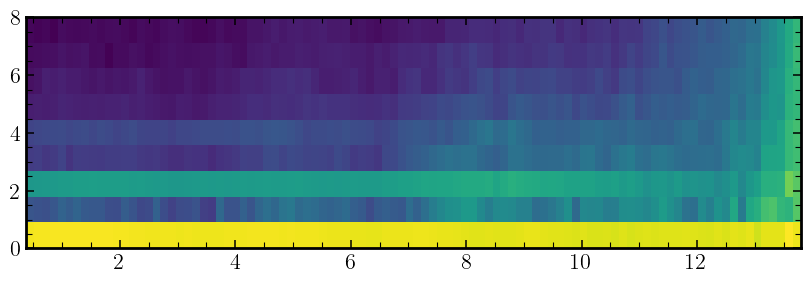

In [125]:
plt.figure(figsize=(10, 3))
plt.imshow(np.log10(coefs.Power().T) , aspect='auto', origin='lower', extent=[t_halo[2], t_halo[99], 0, 8], cmap='viridis')

Text(0.5, 0, '$z$')

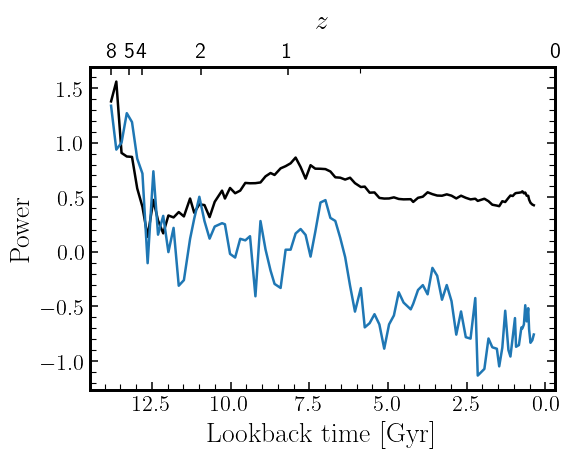

In [151]:
plt.plot(sim_t, np.log10(coefs.Power()[:,2]), lw=1.8, c='k')
plt.plot(sim_t, np.log10(coefs.Power()[:,1]), lw=1.8, c='C0')
plt.gca().invert_xaxis()
plt.xlabel(r'$\rm{Lookback\ time\ [Gyr]}$')
plt.ylabel(r'$\rm{Power}$')

# Add second x-axis on top showing redshift
ax_top = plt.gca().twiny()
ax_top.set_xlim(plt.gca().get_xlim())
# Set tick positions at specific times and label with redshift (reduced number of ticks)
z_ticks = np.array([0, 1, 2, 4, 5, 8])
t_ticks = []
for z in z_ticks:
    idx = np.argmin(np.abs(sim_z - z))
    t_ticks.append(sim_t[idx])
ax_top.set_xticks(t_ticks)
ax_top.set_xticklabels([f'{int(z)}' for z in z_ticks])
# Reduce minor ticks
ax_top.minorticks_on()
ax_top.xaxis.set_minor_locator(plt.MaxNLocator(nbins=2))
ax_top.set_xlabel(r'$z$', labelpad=10)

In [140]:
coefs.Power(0,2).shape

(98, 9)